Warnings

In [1]:
import warnings
warnings.filterwarnings('ignore')

Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading and Exploring Data

In [3]:
data = pd.read_csv('cars_data.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [5]:
data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [17]:
data.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64


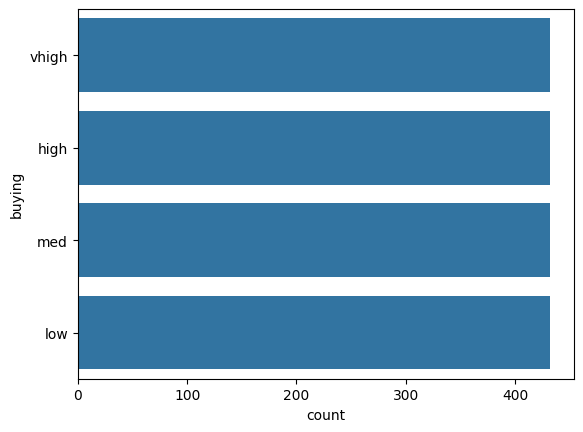

maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64


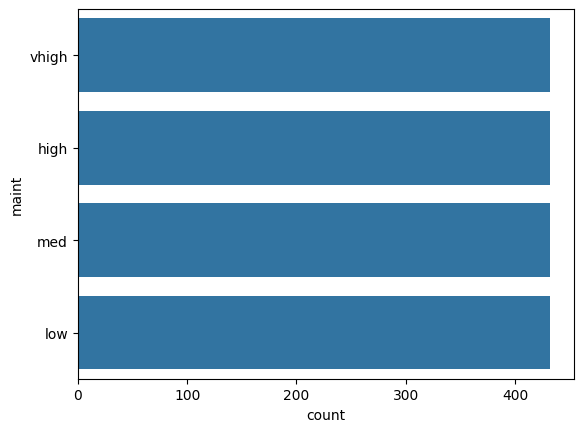

doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64


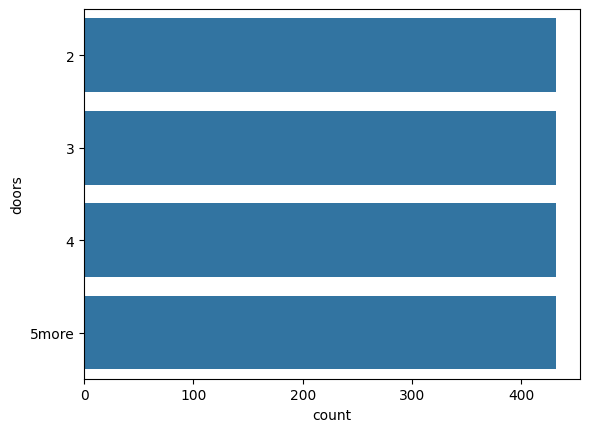

persons
2       576
4       576
more    576
Name: count, dtype: int64


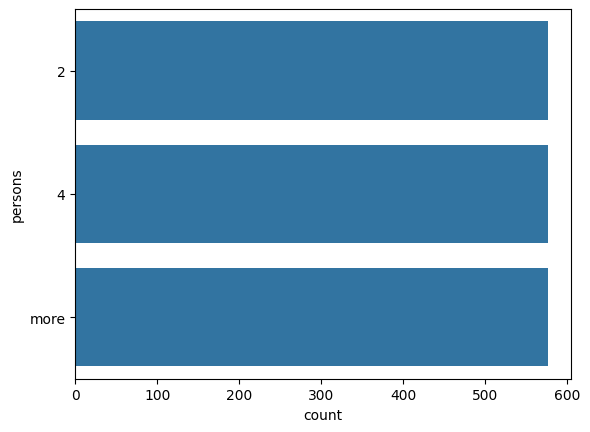

lug_boot
small    576
med      576
big      576
Name: count, dtype: int64


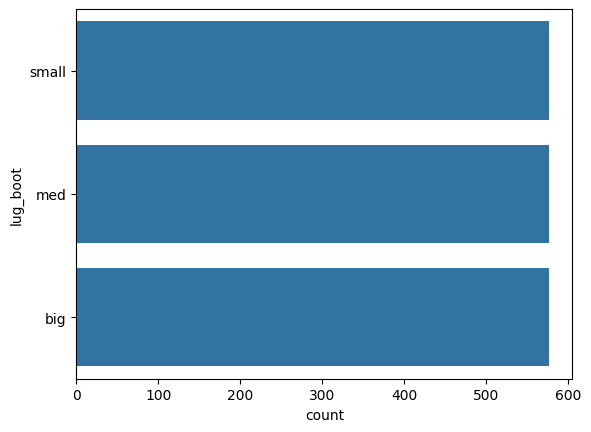

safety
low     576
med     576
high    576
Name: count, dtype: int64


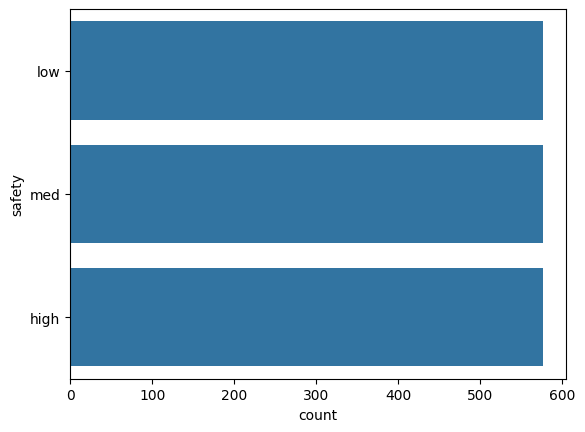

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


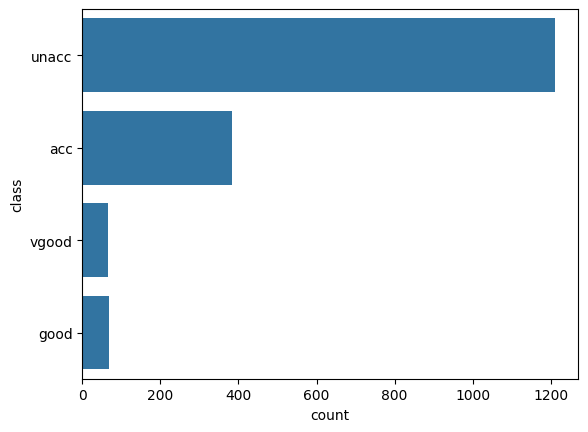

In [19]:
for column in data.columns:
   print(data[column].value_counts())
   sns.countplot(data[column])
   plt.show()

There seems to be large imbalance in the classes

Exploring important features

In [20]:
from scipy.stats import chi2_contingency

In [35]:
for column in data.columns:
    if column != 'class':
        contingency_table = pd.crosstab(data[column], data['class'])
        chisq_stat, p, dof, expected = chi2_contingency(contingency_table)
        print(f"Contingecy Table:\n{contingency_table}")
        print(f"Chi Square statistic for feature {column}: {chisq_stat}")
        print(f"p-value: {p:4f} | {'Reject H0' if p <= .05 else 'Fail to reject H0'}")
        print(f"Degree of Freedom: {dof}")
        print(f"expected frequencies:\n{expected}")

Contingecy Table:
class   acc  good  unacc  vgood
buying                         
high    108     0    324      0
low      89    46    258     39
med     115    23    268     26
vhigh    72     0    360      0
Chi Square statistic for feature buying: 189.24300964187327
p-value: 0.000000 | Reject H0
Degree of Freedom: 9
expected frequencies:
[[ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]]
Contingecy Table:
class  acc  good  unacc  vgood
maint                         
high   105     0    314     13
low     92    46    268     26
med    115    23    268     26
vhigh   72     0    360      0
Chi Square statistic for feature maint: 142.9405303030303
p-value: 0.000000 | Reject H0
Degree of Freedom: 9
expected frequencies:
[[ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]
 [ 96.    17.25 302.5   16.25]]
Contingecy Table:
class  acc  good  unacc  vgood
doors                  

Splitting the data

In [ ]:
X = data.copy(deep=True)
y = X.pop('class')
X = pd.get_dummies(X).replace({True:1, False: 0})
features = X.columns.tolist()

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

Fitting Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
# max_depth= 5 ,
# min_samples_split= 0.01,  90 data points ( 90 rows)- split wont be
#max_features=0.8, - feature bagging - 16 out of 21 features would be used  to find split
#max_samples=0.8  - data bagging - use randomly sampled 80% rows from training data in every decision tree
#n_estimators - number of decision trees - by default 100

In [ ]:
# n_estimators = 100 by default  ( you can try with different values)
# bootstrap ( data row bagging) is True by default
# max_samples = 1

In [68]:
max_depth = 5
min_samples_split = 0.01 # 90 data points
max_features = 0.8 # feature bagging : 16 out of 21 features would be used to find split
max_samples = 0.8 # data bagging - use randomly sampled 80% rows from training data in every decision tree
n_estimators = 100 # number of decision trees : default 100
bootstrap = True # data row bagging
max_samples = None # by default None means use all rows with replacement for every decision tree

In [69]:
model = RandomForestClassifier(random_state=0, max_depth = max_depth, min_samples_split = min_samples_split,
                               max_features = max_features, max_samples = max_features, n_estimators = n_estimators,
                               bootstrap = bootstrap
                               )

In [70]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,0.01
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate Model

In [71]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve

In [72]:
predictions = model.predict(X_test)

In [76]:
print(f"Classification Report:\n{classification_report(y_test, predictions)}")
print(f"Accuracy Score: {accuracy_score(y_test, predictions)}")

Classification Report:
              precision    recall  f1-score   support

         acc       0.73      0.94      0.82        83
        good       0.00      0.00      0.00        11
       unacc       0.98      1.00      0.99       235
       vgood       0.00      0.00      0.00        17

    accuracy                           0.90       346
   macro avg       0.43      0.48      0.45       346
weighted avg       0.84      0.90      0.87       346

Accuracy Score: 0.9017341040462428


Searching for best parameters

In [77]:
from sklearn.model_selection import GridSearchCV

In [ ]:
parameter_grid = [
    {
        'max_depth': [3,5,7,10], 
        'min_samples_split': [0.01, 0.03, 0.07, 0.1], 
        'max_features': [0.7, 0.8, 0.9, 1.0],
        'max_samples': [0.7, 0.8, 0.9,1.0]
    }
]

In [80]:
gsModel = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parameter_grid, cv=5, verbose=5)

In [81]:
gsModel.fit(X_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.819 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.838 total time=   0.0s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.797 total time=   0.0s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.819 total time=   0.0s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.786 total time=   0.0s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.823 total time=   0.0s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.845 total time=   0.0s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.822 total time=   0.0s


,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [3, 5, ...], 'max_features': [0.7, 0.8, ...], 'max_samples': [0.7, 0.8, ...], 'min_samples_split': [0.01, 0.03, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [82]:
search_results = pd.DataFrame(gsModel.cv_results_)

In [85]:
search_results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [88]:
search_results.to_csv('grid_search_results.csv', index=False)

In [87]:
gsModel.best_params_

{'max_depth': 10,
 'max_features': 1.0,
 'max_samples': 0.9,
 'min_samples_split': 0.01}

In [90]:
model_mk2 = gsModel.best_estimator_

Evaluating Mk2 Model

In [94]:
predictions = model_mk2.predict(X_test)
print(f"Classification Report:\n{classification_report(y_test, predictions)}")
print(f"Accuracy Score: {accuracy_score(y_test, predictions)}")

Classification Report:
              precision    recall  f1-score   support

         acc       0.99      0.88      0.93        83
        good       0.56      0.82      0.67        11
       unacc       1.00      1.00      1.00       235
       vgood       0.81      1.00      0.89        17

    accuracy                           0.96       346
   macro avg       0.84      0.92      0.87       346
weighted avg       0.97      0.96      0.96       346

Accuracy Score: 0.9624277456647399


Global Feature Importance

In [98]:
df = pd.DataFrame(
    {
        'Feature': features,
        'Importance': model_mk2.feature_importances_
    }
)

In [99]:
df.sort_values(by='Importance', ascending=False, inplace=True)

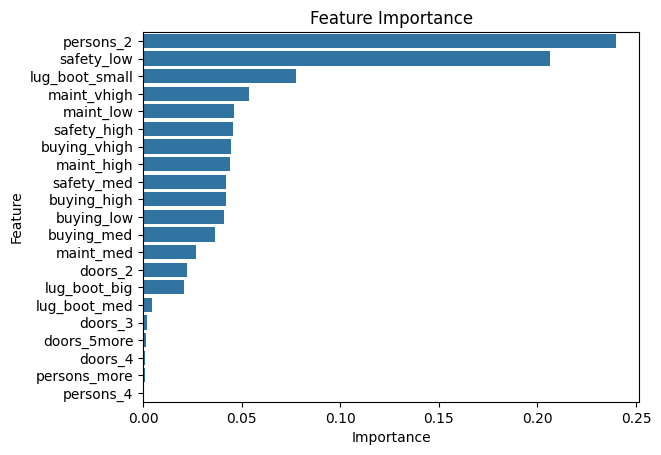

In [101]:
fig = plt.figure()
sns.barplot(data=df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.show()